# Autocatalytic Loop Collapse Experiments

Spatial stochastic simulation of the self-maintenance loop in dormant yeast spores.

**The loop:** RNAP transcribes its own gene and the ribosome gene; ribosomes translate both mRNAs.
The system dies when this autocatalytic cycle can no longer sustain itself.

**Death metric:** Two independent cycles in the production graph:
- **Cycle 1 (RNAP renewal):** `P > 0 ∧ mP > 0 ∧ R > 0 ∧ ATP > 0`
- **Cycle 2 (Ribosome self-renewal):** `R > 0 ∧ mR > 0 ∧ ATP > 0`

Functional death = both cycles inactive (after t=0). Point of no return (PNR) = Cycle 1 breaks irreversibly while Cycle 2 persists ("walking dead").

## 1. Setup

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pyrdme import Lattice2D, Reaction, MPDSolver, simulate_rdme
from pyrdme.ensemble import run_ensemble, make_param_grid

# --- Dimensionless units ---
# Length: λ = lattice spacing = 1
# Time:   τ = λ² / D_mRNA = 1  (one mRNA diffusion time across a site)
#
# Physical reference (for converting back):
#   λ_phys = 1 μm,  D_mRNA_phys = 5e-13 m²/s  →  τ_phys = 2.0 s

# --- Species ---
SPECIES = ['P', 'R', 'mP', 'mR']

# --- Lattice ---
# 10×10, spacing = 1 (dimensionless)
def make_lattice(N_RNAP=20, N_Ribo=20):
    lattice = Lattice2D(nx=10, ny=10, species=SPECIES, spacing=1.0)
    lattice.set_site_type((slice(1, 3), slice(1, 3)), 'rnap_gene')
    lattice.set_site_type((slice(7, 9), slice(7, 9)), 'ribo_gene')
    lattice.add_particles('P', count=N_RNAP)
    lattice.add_particles('R', count=N_Ribo)
    return lattice

# --- Diffusion (dimensionless, relative to D_mRNA = 1) ---
DIFFUSION = {
    'P':  0.2,   # RNAP:     D_phys / D_mRNA = 1e-13 / 5e-13
    'R':  0.1,   # Ribosome: D_phys / D_mRNA = 0.5e-13 / 5e-13
    'mP': 1.0,   # mRNA (reference)
    'mR': 1.0,
}

print("Dimensionless units: λ=1 (lattice spacing), τ=λ²/D_mRNA=1")
print(f"Physical scales: λ=1 μm, τ=2.0 s")
print(f"Species: {SPECIES}")
print(f"Diffusion: {DIFFUSION}")

Dimensionless units: λ=1 (lattice spacing), τ=λ²/D_mRNA=1
Physical scales: λ=1 μm, τ=2.0 s
Species: ['P', 'R', 'mP', 'mR']
Diffusion: {'P': 0.2, 'R': 0.1, 'mP': 1.0, 'mR': 1.0}


## 2. Reactions

8 reactions in dimensionless units (rates in 1/τ where τ = λ²/D_mRNA).

| # | Reaction | Rate (1/τ) | Site gate | ATP cost |
|---|----------|------------|-----------|----------|
| R0 | P → P + mP | k_tx = 0.1 | rnap_gene | 1 |
| R1 | P → P + mR | k_tx = 0.1 | ribo_gene | 1 |
| R2 | R + mP → R + mP + P | k_tl = 0.004 | — | 1 |
| R3 | R + mR → R + mR + R | k_tl = 0.004 | — | 1 |
| R4 | mP → ∅ | k_deg_m = 0.01 | — | — |
| R5 | mR → ∅ | k_deg_m = 0.01 | — | — |
| R6 | P → ∅ | k_deg_p = 0.001 | — | — |
| R7 | R → ∅ | k_deg_p = 0.001 | — | — |

Conversion: k_dimless = k_phys × τ_phys (where τ_phys = 2.0 s).

In [31]:
# Rate constants (dimensionless, in units of 1/τ)
# Conversion: k_dimless = k_phys × τ_phys,  τ_phys = 2.0 s
k_tx    = 0.1     # transcription rate per RNAP at gene locus  (phys: 0.05/s)
k_tl    = 0.004   # translation rate per ribosome-mRNA pair    (phys: 0.002/s)
k_deg_m = 0.01    # mRNA degradation, half-life ~70 τ          (phys: 0.005/s)
k_deg_p = 0.001   # protein degradation, half-life ~700 τ      (phys: 0.0005/s)

# Transcription (catalytic in P, site-gated)
R0 = Reaction(['P'], ['P', 'mP'], k=k_tx)
R1 = Reaction(['P'], ['P', 'mR'], k=k_tx)

# Translation (catalytic in R and mRNA)
R2 = Reaction(['R', 'mP'], ['R', 'mP', 'P'], k=k_tl)
R3 = Reaction(['R', 'mR'], ['R', 'mR', 'R'], k=k_tl)

# Degradation
R4 = Reaction(['mP'], [], k=k_deg_m)
R5 = Reaction(['mR'], [], k=k_deg_m)
R6 = Reaction(['P'], [], k=k_deg_p)
R7 = Reaction(['R'], [], k=k_deg_p)

REACTIONS = [R0, R1, R2, R3, R4, R5, R6, R7]

REACTION_SITES = {
    0: 'rnap_gene',
    1: 'ribo_gene',
}

REACTION_COSTS = {
    0: {'ATP': 1},
    1: {'ATP': 1},
    2: {'ATP': 1},
    3: {'ATP': 1},
}

print(f"Defined {len(REACTIONS)} reactions (dimensionless rates)")
print(f"mRNA half-life: {np.log(2)/k_deg_m:.0f} τ  ({np.log(2)/k_deg_m * 2:.0f} s)")
print(f"Protein half-life: {np.log(2)/k_deg_p:.0f} τ  ({np.log(2)/k_deg_p * 2:.0f} s)")

Defined 8 reactions (dimensionless rates)
mRNA half-life: 69 τ  (139 s)
Protein half-life: 693 τ  (1386 s)


## 3. Simulation Function

Custom `run_single_sim()` with cycle-based death detection (D5).
Returns lightweight summary dict for ensemble collection.

In [32]:
def _check_cycles(lattice, solver, idx_P, idx_R, idx_mP, idx_mR):
    """Return (cycle1_active, cycle2_active, counts tuple)."""
    P = int(np.sum(lattice.counts[idx_P]))
    R = int(np.sum(lattice.counts[idx_R]))
    mP = int(np.sum(lattice.counts[idx_mP]))
    mR = int(np.sum(lattice.counts[idx_mR]))
    ATP = solver.global_resources['ATP']

    cycle1 = (P > 0) and (mP > 0) and (R > 0) and (ATP > 0)
    cycle2 = (R > 0) and (mR > 0) and (ATP > 0)
    return cycle1, cycle2, (P, R, mP, mR, ATP)


def run_single_sim(N_RNAP=20, N_Ribo=20, N_ATP=1000, seed=None,
                    t_max=50000.0, dt=None, return_trajectory=False):
    """
    Run one spore dormancy simulation with cycle-based death detection.

    Death requires an IRRECOVERABLE condition, not just transient cycle
    inactivity (mRNA can fluctuate to 0 while RNAP is still present):

    - Ribo depletion:   R = 0  (absorbing — autocatalytic, no recovery)
    - ATP depletion:    ATP = 0  (all production stops)
    - Cycle collapse:   P = 0 ∧ mP = 0 (RNAP irrecoverable = PNR),
                        THEN wait for Cycle 2 to also break (functional death)
    """
    lattice = make_lattice(N_RNAP, N_Ribo)
    solver = MPDSolver(
        lattice, REACTIONS, DIFFUSION, seed=seed,
        reaction_sites=REACTION_SITES,
        global_resources={'ATP': N_ATP},
        reaction_costs=REACTION_COSTS,
    )

    if dt is None:
        dt = solver.get_max_timestep() * 0.9

    idx_P = lattice.species_index('P')
    idx_R = lattice.species_index('R')
    idx_mP = lattice.species_index('mP')
    idx_mR = lattice.species_index('mR')

    def _make_result(t, death_mode, t_pnr, trajectory):
        result = {
            't_death': t,
            'death_mode': death_mode,
            't_pnr': t_pnr,
            'dt_walking_dead': (t - t_pnr) if t_pnr is not None else 0.0,
            'N_RNAP': N_RNAP, 'N_Ribo': N_Ribo, 'N_ATP': N_ATP, 'seed': seed,
        }
        if return_trajectory:
            result['trajectory'] = trajectory
        return result

    t = 0.0
    t_pnr = None
    trajectory = [] if return_trajectory else None

    # Record initial state
    if return_trajectory:
        _, _, counts = _check_cycles(lattice, solver, idx_P, idx_R, idx_mP, idx_mR)
        P, R, mP, mR, ATP = counts
        trajectory.append({'t': 0.0, 'P': P, 'R': R, 'mP': mP, 'mR': mR, 'ATP': ATP})

    # Immediate death: if P=0 or R=0 or ATP=0 at t=0, loop can never bootstrap
    _, _, counts = _check_cycles(lattice, solver, idx_P, idx_R, idx_mP, idx_mR)
    P, R, mP, mR, ATP = counts
    if R == 0:
        return _make_result(0.0, 'ribo_depletion', None, trajectory)
    if P == 0:
        return _make_result(0.0, 'cycle_collapse', None, trajectory)
    if ATP <= 0:
        return _make_result(0.0, 'atp_depletion', None, trajectory)

    while t < t_max:
        solver.step(dt)
        t += dt

        c1, c2, counts = _check_cycles(lattice, solver, idx_P, idx_R, idx_mP, idx_mR)
        P, R, mP, mR, ATP = counts

        if return_trajectory and (len(trajectory) == 0 or t - trajectory[-1]['t'] >= dt * 10):
            trajectory.append({'t': t, 'P': P, 'R': R, 'mP': mP, 'mR': mR, 'ATP': ATP})

        # --- Check irrecoverable conditions ---

        # 1. Ribosome = 0: absorbing wall, instant death
        if R == 0:
            return _make_result(t, 'ribo_depletion', t_pnr, trajectory)

        # 2. ATP = 0: all production stops
        if ATP <= 0:
            return _make_result(t, 'atp_depletion', t_pnr, trajectory)

        # 3. Cycle collapse: P=0 AND mP=0 → RNAP irrecoverable (PNR)
        rnap_irrecoverable = (P == 0) and (mP == 0)
        if rnap_irrecoverable and t_pnr is None:
            t_pnr = t

        # Functional death: PNR reached AND Cycle 2 also broke
        if rnap_irrecoverable and not c2:
            return _make_result(t, 'cycle_collapse', t_pnr, trajectory)

    return _make_result(t_max, 'survived', t_pnr, trajectory)

print("run_single_sim() defined")

run_single_sim() defined


## 4. Single Trajectory Sanity Check

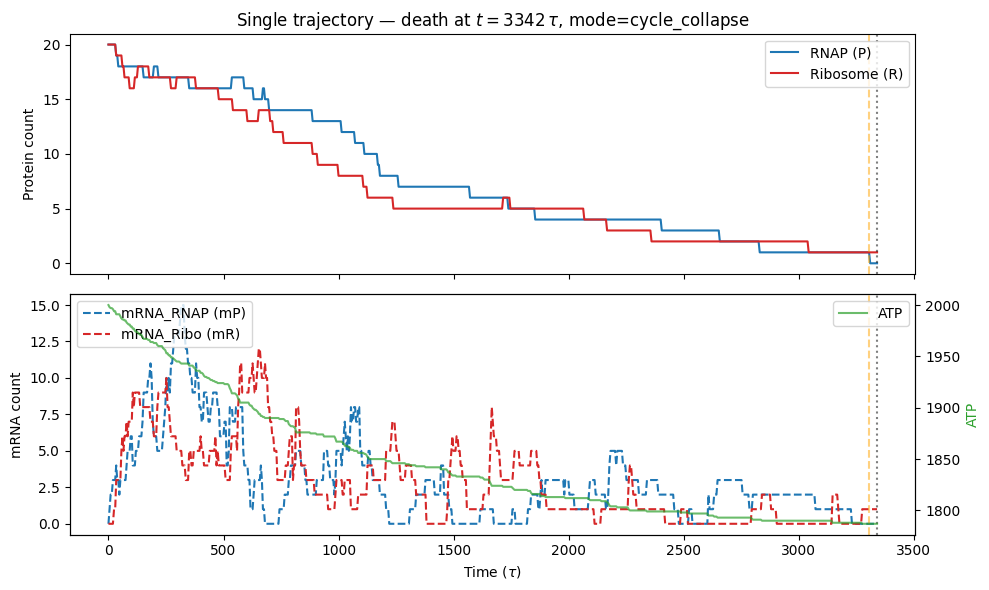

Death time: 3341.7 τ 
Death mode: cycle_collapse
PNR time: 3307.0499999996373
Walking dead duration: 34.6 τ


In [41]:
# Run a single trajectory with moderate initial conditions
result = run_single_sim(N_RNAP=20, N_Ribo=20, N_ATP=2000, seed=42,
                         return_trajectory=True)

traj = result['trajectory']
ts = [p['t'] for p in traj]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Proteins
ax = axes[0]
ax.plot(ts, [p['P'] for p in traj], label='RNAP (P)', color='tab:blue')
ax.plot(ts, [p['R'] for p in traj], label='Ribosome (R)', color='tab:red')
ax.set_ylabel('Protein count')
ax.legend(loc='upper right')
ax.set_title(rf"Single trajectory — death at $t={result['t_death']:.0f}\,\tau$, mode={result['death_mode']}")

# mRNAs + ATP
ax = axes[1]
ax.plot(ts, [p['mP'] for p in traj], label='mRNA_RNAP (mP)', color='tab:blue', ls='--')
ax.plot(ts, [p['mR'] for p in traj], label='mRNA_Ribo (mR)', color='tab:red', ls='--')
ax2 = ax.twinx()
ax2.plot(ts, [p['ATP'] for p in traj], label='ATP', color='tab:green', alpha=0.7)
ax2.set_ylabel('ATP', color='tab:green')
ax.set_ylabel('mRNA count')
ax.set_xlabel(r'Time ($\tau$)')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

# Mark death and PNR
for a in axes:
    a.axvline(result['t_death'], color='black', ls=':', alpha=0.5, label='death')
    if result['t_pnr'] is not None:
        a.axvline(result['t_pnr'], color='orange', ls='--', alpha=0.5, label='PNR')

plt.tight_layout()
plt.show()

print(f"Death time: {result['t_death']:.1f} τ ")
print(f"Death mode: {result['death_mode']}")
print(f"PNR time: {result['t_pnr']}")
print(f"Walking dead duration: {result['dt_walking_dead']:.1f} τ")

## 5. Parameter Sweep

20×20 log-spaced grid for each heatmap pair, 200 seeds per point.

**Warning:** The full sweep is ~240k simulations and takes hours.
Set `N_SEEDS` and grid resolution below to run a quick test.

In [34]:
# --- Sweep configuration ---
# For a quick test, reduce these. Full run: N_GRID=20, N_SEEDS=200
N_GRID = 8          # grid points per axis
N_SEEDS = 10         # seeds per parameter point
T_MAX = 50000.0      # max sim time in τ 

# Log-spaced axes
RNAP_AXIS = np.unique(np.logspace(np.log10(2), np.log10(100), N_GRID).astype(int))
RIBO_AXIS = np.unique(np.logspace(np.log10(2), np.log10(100), N_GRID).astype(int))
ATP_AXIS = [1000]    # held fixed for RNAP×Ribo sweep

print(f"RNAP axis: {RNAP_AXIS.tolist()}")
print(f"Ribo axis: {RIBO_AXIS.tolist()}")
print(f"Seeds per point: {N_SEEDS}")
print(f"T_MAX = {T_MAX:.0f} τ  ({T_MAX * 2:.0f} s physical)")
print(f"Total runs (RNAP×Ribo sweep): {len(RNAP_AXIS) * len(RIBO_AXIS) * N_SEEDS}")

RNAP axis: [2, 3, 6, 10, 18, 32, 57, 100]
Ribo axis: [2, 3, 6, 10, 18, 32, 57, 100]
Seeds per point: 10
T_MAX = 50000 τ  (100000 s physical)
Total runs (RNAP×Ribo sweep): 640


In [ ]:
# --- Run RNAP × Ribo sweep (ATP fixed) ---
grid_pr = make_param_grid(
    N_RNAP=RNAP_AXIS.tolist(),
    N_Ribo=RIBO_AXIS.tolist(),
    N_ATP=ATP_AXIS,
    seeds=range(N_SEEDS),
    t_max=[T_MAX],
)
print(f"Running {len(grid_pr)} simulations (RNAP × Ribo)...")
results_pr = run_ensemble(run_single_sim, grid_pr, progress=True)
print(f"Done. {len(results_pr)} results collected.")

## 6. Phase Diagrams

In [ ]:
def aggregate_results(results, x_key, y_key, x_axis, y_axis):
    """Aggregate ensemble results into 2D grids for plotting."""
    nx, ny = len(x_axis), len(y_axis)
    x_map = {v: i for i, v in enumerate(x_axis)}
    y_map = {v: i for i, v in enumerate(y_axis)}

    mode_names = ['ribo_depletion', 'cycle_collapse', 'atp_depletion', 'survived']
    death_counts = {mode: np.zeros((nx, ny)) for mode in mode_names}
    t_death_sum = np.zeros((nx, ny))
    t_death_n = np.zeros((nx, ny))
    wd_sum = np.zeros((nx, ny))
    wd_n = np.zeros((nx, ny))

    for r in results:
        xi = x_map.get(r[x_key])
        yi = y_map.get(r[y_key])
        if xi is None or yi is None:
            continue
        mode = r['death_mode']
        if mode in death_counts:
            death_counts[mode][xi, yi] += 1
        t_death_sum[xi, yi] += r['t_death']
        t_death_n[xi, yi] += 1
        if r['dt_walking_dead'] > 0:
            wd_sum[xi, yi] += r['dt_walking_dead']
            wd_n[xi, yi] += 1

    # Mode fractions per pixel (for continuous RGB)
    # R = ribo_depletion, G = cycle_collapse, B = atp_depletion
    total = t_death_n.copy()
    total[total == 0] = 1  # avoid division by zero
    frac_ribo = death_counts['ribo_depletion'] / total
    frac_cycle = death_counts['cycle_collapse'] / total
    frac_atp = death_counts['atp_depletion'] / total
    frac_survived = death_counts['survived'] / total

    # RGB image: each pixel is a blend of mode colors weighted by fraction
    # Ribo = blue (#4477AA), Cycle = red (#CC3311), ATP = green (#228833)
    # Survived maps to gray
    rgb = np.zeros((nx, ny, 3))
    c_ribo    = np.array([0x44, 0x77, 0xAA]) / 255.0
    c_cycle   = np.array([0xCC, 0x33, 0x11]) / 255.0
    c_atp     = np.array([0x22, 0x88, 0x33]) / 255.0
    c_survived = np.array([0.75, 0.75, 0.75])
    for ch in range(3):
        rgb[:, :, ch] = (frac_ribo * c_ribo[ch]
                       + frac_cycle * c_cycle[ch]
                       + frac_atp * c_atp[ch]
                       + frac_survived * c_survived[ch])

    mean_t_death = np.divide(t_death_sum, t_death_n, where=t_death_n > 0,
                             out=np.zeros_like(t_death_sum))
    mean_wd = np.divide(wd_sum, wd_n, where=wd_n > 0,
                        out=np.zeros_like(wd_sum))

    # Dominant mode grid (for walking-dead overlay masking)
    mode_grid = np.zeros((nx, ny), dtype=int)
    for i in range(nx):
        for j in range(ny):
            counts = [death_counts[m][i, j] for m in mode_names]
            mode_grid[i, j] = np.argmax(counts)

    return rgb, mode_grid, mean_t_death, mean_wd, mode_names


rgb_pr, mode_pr, t_death_pr, wd_pr, mode_names = aggregate_results(
    results_pr, 'N_RNAP', 'N_Ribo', RNAP_AXIS, RIBO_AXIS
)
print("Aggregation complete.")

In [ ]:
# --- Layer 1: Continuous RGB Phase Diagram ---
# Each pixel is a weighted blend of mode colors by fraction of runs.
# Pure color = 100% one mode. White-ish = equal mix. Smooth transitions at boundaries.

from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(8, 6))
# imshow expects (rows, cols, 3) with rows=y, so transpose the first two axes
ax.imshow(np.transpose(rgb_pr, (1, 0, 2)), origin='lower', aspect='auto',
          interpolation='nearest')
ax.set_xticks(range(len(RNAP_AXIS)))
ax.set_xticklabels(RNAP_AXIS)
ax.set_yticks(range(len(RIBO_AXIS)))
ax.set_yticklabels(RIBO_AXIS)
ax.set_xlabel('Initial RNAP')
ax.set_ylabel('Initial Ribosome')
ax.set_title('Loop Collapse Mode (N_RNAP × N_Ribo)')

# Legend with the pure-mode colors
c_ribo   = (0x44/255, 0x77/255, 0xAA/255)
c_cycle  = (0xCC/255, 0x33/255, 0x11/255)
c_atp    = (0x22/255, 0x88/255, 0x33/255)
c_surv   = (0.75, 0.75, 0.75)
legend_elements = [
    Patch(facecolor=c_ribo,  label='Ribo depletion'),
    Patch(facecolor=c_cycle, label='Cycle collapse'),
    Patch(facecolor=c_atp,   label='ATP depletion'),
    Patch(facecolor=c_surv,  label='Survived'),
]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# --- Layer 2: Mean Cessation Time Heatmap ---
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(t_death_pr.T, origin='lower', aspect='auto', cmap='viridis',
               interpolation='nearest')
ax.set_xticks(range(len(RNAP_AXIS)))
ax.set_xticklabels(RNAP_AXIS)
ax.set_yticks(range(len(RIBO_AXIS)))
ax.set_yticklabels(RIBO_AXIS)
ax.set_xlabel('Initial RNAP')
ax.set_ylabel('Initial Ribosome')
ax.set_title('Mean Cessation Time (N_RNAP × N_Ribo)')
cbar = plt.colorbar(im, ax=ax, label=r'Mean $t_{death}$ ($\tau$)')
plt.tight_layout()
plt.show()

In [ ]:
# --- Layer 3: Walking Dead Duration Overlay ---
# Mask to cycle-collapse region only (index 1 in mode_names)
wd_masked = np.ma.masked_where(mode_pr != 1, wd_pr)

fig, ax = plt.subplots(figsize=(8, 6))
# Background: continuous RGB phase diagram (faded)
bg = rgb_pr.copy()
bg = 0.3 * bg + 0.7  # wash out toward white
ax.imshow(np.transpose(bg, (1, 0, 2)), origin='lower', aspect='auto',
          interpolation='nearest')
# Overlay: walking dead duration in cycle-collapse region
im = ax.imshow(wd_masked.T, origin='lower', aspect='auto', cmap='Oranges',
               interpolation='nearest')
ax.set_xticks(range(len(RNAP_AXIS)))
ax.set_xticklabels(RNAP_AXIS)
ax.set_yticks(range(len(RIBO_AXIS)))
ax.set_yticklabels(RIBO_AXIS)
ax.set_xlabel('Initial RNAP')
ax.set_ylabel('Initial Ribosome')
ax.set_title('Walking Dead Duration (cycle-collapse region)')
cbar = plt.colorbar(im, ax=ax, label=r'Mean $\Delta t_{wd}$ ($\tau$)')
plt.tight_layout()
plt.show()

## 7. Lifetime Distributions

In [ ]:
# Select a few parameter points near phase boundaries
sample_points = [
    {'N_RNAP': int(RNAP_AXIS[1]), 'N_Ribo': int(RIBO_AXIS[-2])},  # low P, high R
    {'N_RNAP': int(RNAP_AXIS[-2]), 'N_Ribo': int(RIBO_AXIS[1])},  # high P, low R
    {'N_RNAP': int(RNAP_AXIS[len(RNAP_AXIS)//2]), 'N_Ribo': int(RIBO_AXIS[len(RIBO_AXIS)//2])},  # mid
]

fig, axes = plt.subplots(1, len(sample_points), figsize=(5*len(sample_points), 4), sharey=True)
if len(sample_points) == 1:
    axes = [axes]

for ax, sp in zip(axes, sample_points):
    lifetimes = [r['t_death'] for r in results_pr
                 if r['N_RNAP'] == sp['N_RNAP'] and r['N_Ribo'] == sp['N_Ribo']]

    if lifetimes:
        ax.hist(lifetimes, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
        ax.set_xlabel(r'$t_{death}$ ($\tau$)')
        ax.set_title(f"P={sp['N_RNAP']}, R={sp['N_Ribo']}")
    else:
        ax.set_title(f"P={sp['N_RNAP']}, R={sp['N_Ribo']} (no data)")

axes[0].set_ylabel('Count')
plt.suptitle('Lifetime Distributions at Selected Points')
plt.tight_layout()
plt.show()

## 8. Example Trajectories

Representative runs from each death-mode region, with PNR and death annotated.

In [ ]:
# Run representative trajectories for each collapse mode
example_params = {
    'Ribo depletion\n(low R, high P)': dict(N_RNAP=50, N_Ribo=3, N_ATP=2000, seed=7),
    'Cycle collapse\n(low P, high R)': dict(N_RNAP=3, N_Ribo=50, N_ATP=2000, seed=12),
    'ATP depletion\n(moderate both, low ATP)': dict(N_RNAP=30, N_Ribo=30, N_ATP=200, seed=5),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, params) in zip(axes, example_params.items()):
    res = run_single_sim(**params, return_trajectory=True)
    traj = res['trajectory']
    if not traj:
        ax.set_title(f"{title}\n(no trajectory)")
        continue
    ts = [p['t'] for p in traj]
    ax.plot(ts, [p['P'] for p in traj], label='P', color='tab:blue')
    ax.plot(ts, [p['R'] for p in traj], label='R', color='tab:red')
    ax.plot(ts, [p['mP'] for p in traj], label='mP', color='tab:blue', ls='--', alpha=0.6)
    ax.plot(ts, [p['mR'] for p in traj], label='mR', color='tab:red', ls='--', alpha=0.6)

    ax.axvline(res['t_death'], color='black', ls=':', lw=1.5,
               label=f"{res['death_mode']}")
    if res['t_pnr'] is not None:
        ax.axvline(res['t_pnr'], color='orange', ls='--', lw=1.5,
                   label=rf"PNR ($\Delta t_{{wd}}$={res['dt_walking_dead']:.0f}$\tau$)")

    ax.set_xlabel(r'Time ($\tau$)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Example Trajectories by Collapse Mode', fontsize=13)
plt.tight_layout()
plt.show()